In [3]:
# load packages
from pyfiles.preamble import *
enable_autoreload()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Get standardised output *on demand*

### 1. Create output

Run scenario(s), by defining an inputfile of interest and a corresponding outputfile that will be placed in the `/runs` folder. `all_paths` saves to parquet for efficiency, if needed this can be converted to excel as shown below.

In [4]:
inp_files = ['example_base', 'example_shock']
inp_names = ['Base scenario', 'Shock scenario']

In [5]:
# # parquet files for python interaction (efficient)
# res_parquet = ep_run.run_scenarios(inp_files)

# # print to excel if necessary
# res_excel = ep_to_excel.to_excel(
#     out_names=inp_files,
#     excel_path=ep_run.DEFAULT_OUT_DIR / 'runs_overview.xlsx',
# )

*just run `res_parquet` once, all the below uses the output files only.*

### 2. Visualise

First, get a general overview of the scenario by assessing the totwl costs

In [6]:
# or in one call
all = ep_costs.get_costs_all(inp_files)

# print
all

,Variable costs,Fixed operation costs,Annual Investment costs,TOTAL ANNUAL COSTS
Case (M EUR),,,,
example_base,1543.0,4965.0,19635.0,26143.0
example_shock,1768.0,4980.0,19566.0,26314.0


Then plot the monthly and hourly timeseries for a chosen selection of variables.

In [7]:
# list of relevant variables
core_vars = [
    'PV_Electr.', 'Offshore_Electr.', 'Nuclear_Electr.', 'PP2_Electr.', 
    'H2_prod.', 'H2_Storage',
]

*use the below to get an overview of all variables*

In [17]:
for k, v in labels.items():
    print(f'{k:35s}  {v}')

Electr._Demand                       Electricity demand
Elec.dem_Cooling                     Electricity demand for cooling
Flexible_Electr.                     Flexible electricity demand
Fixed_Exp/Imp                        Fixed exchange
DH_Demand                            District heating demand
Stabil._Load                         Stabilisation load
Wind_Electr.                         Onshore wind
Offshore_Electr.                     Offshore wind
PV_Electr.                           Solar PV
River_Electr.                        Run-of-river hydro
Tidal_Electr.                        Tidal
Wave_Electr.                         Wave
CSP_Electr.                          CSP (electricity)
CSP2_Electr.                         CSP2 (electricity)
CSP2_Storage                         CSP2 storage
CSP2_loss                            CSP2 losses
Hydro_Electr.                        Hydro (electricity)
Hydro_pump                           Hydro pump
Hydro_storage                        Hy

*plot monthly*

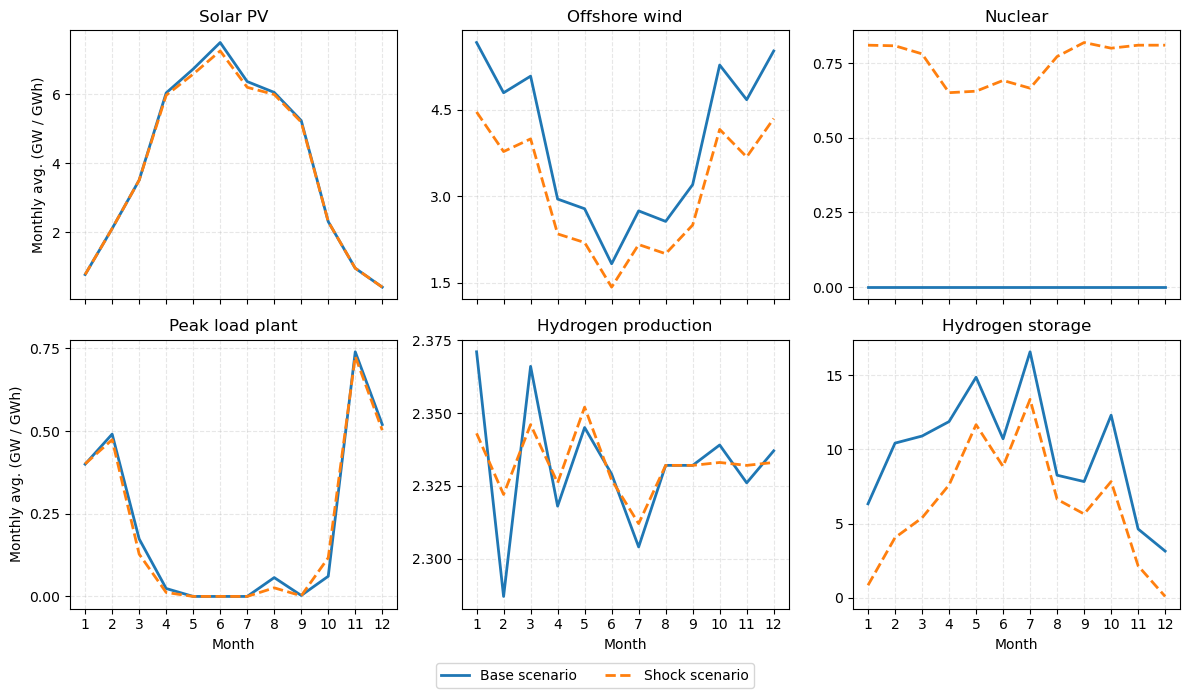

In [8]:
ep_plot.plot_monthly(
    names=inp_files, 
    variables=core_vars, 
    inp_names=inp_names
);

*plot hourly*

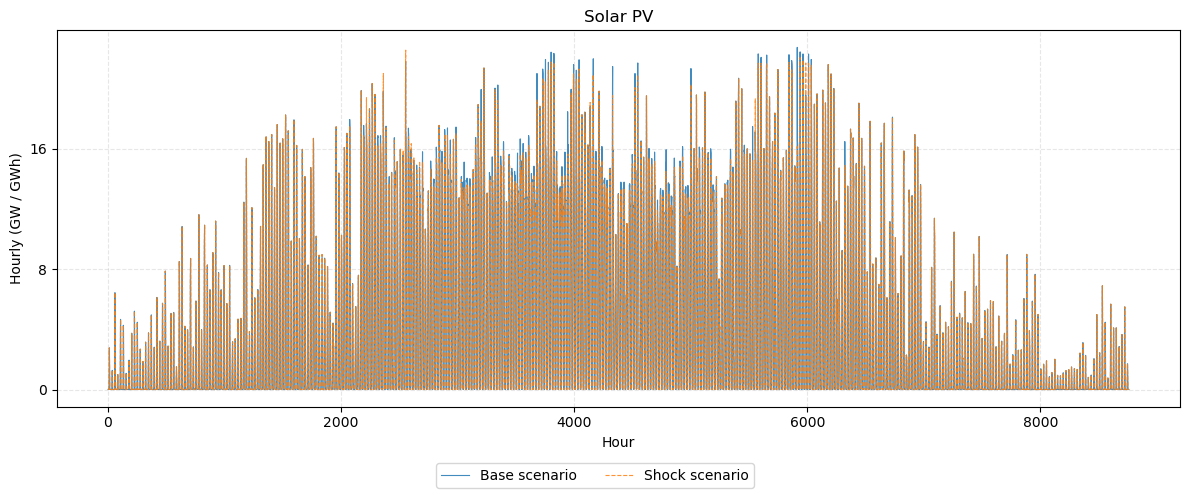

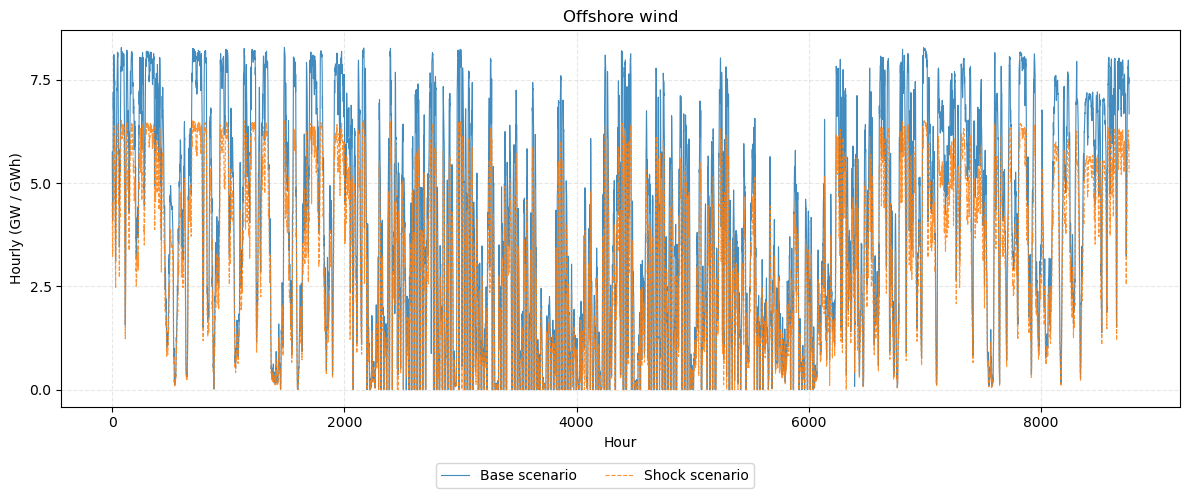

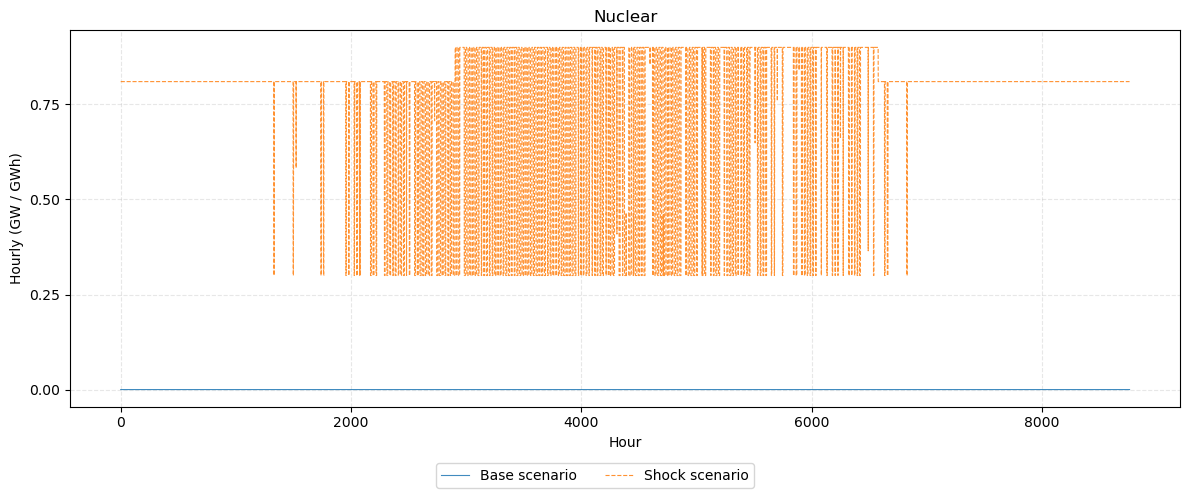

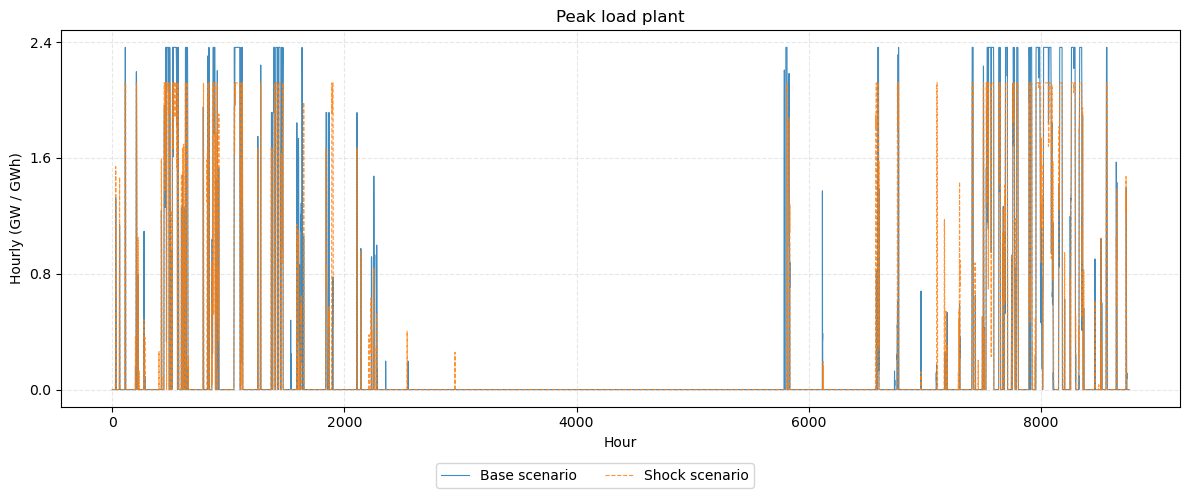

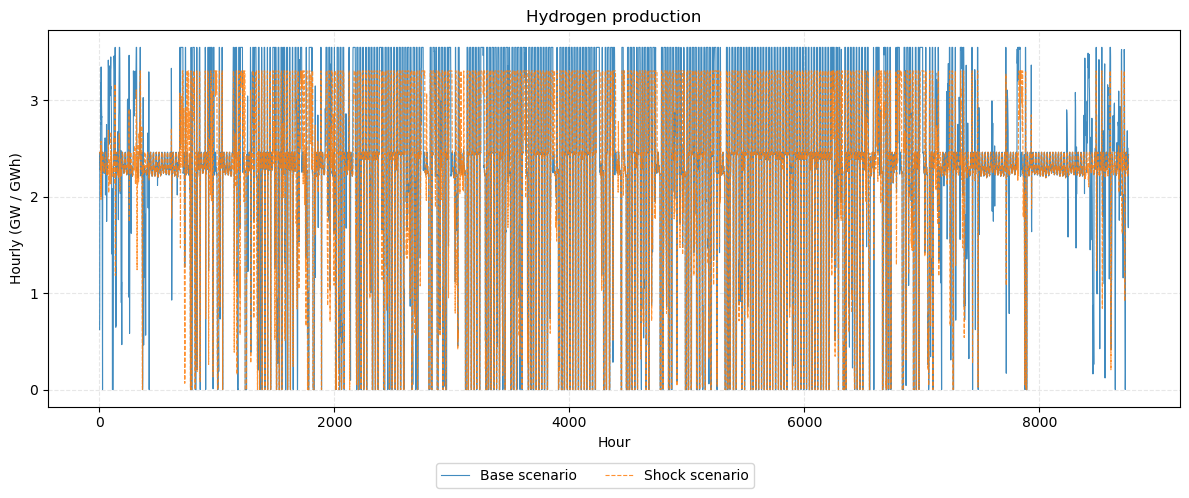

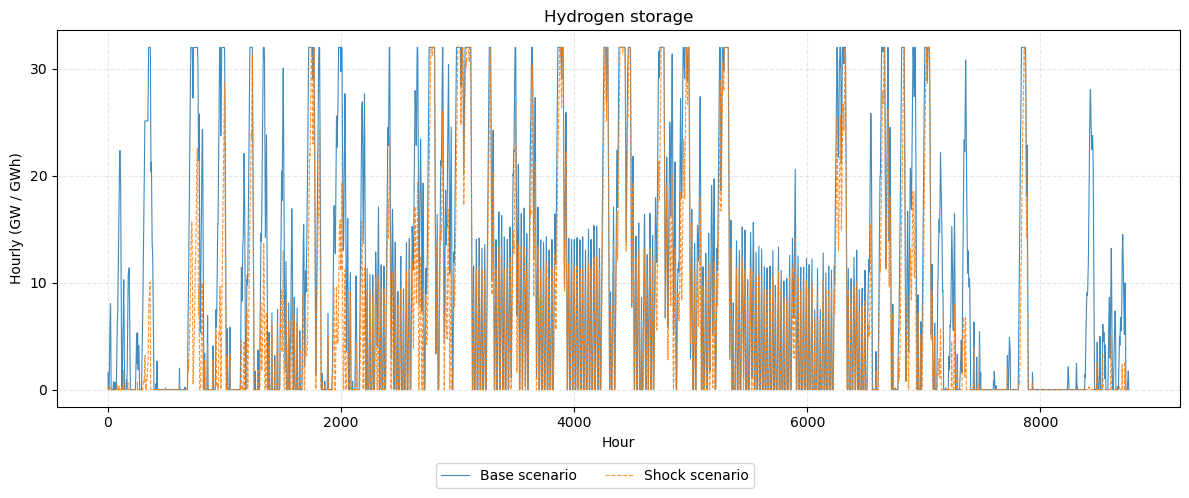

In [9]:
ep_plot.plot_hourly(
    names=inp_files, 
    variables=core_vars, 
    inp_names=inp_names
);